# RED NEURONAL CONVOLUCIONAL PARA CLASIFICACIÓN DE IMAGENES DE PERROS Y GATOS
## DATASET [KAGGLE](https://www.kaggle.com/competitions/dogs-vs-cats/overview)

# 1 - GARGAMOS IMAGENES PARA EL DATASET

## IMPORTAMOS LIBRERIAS

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
BASE_DIR = '/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets'

# CARGAMOS PATH DE IMAGENES

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [48]:
import os
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALIDATION_DIR = os.path.join(BASE_DIR, 'validation')
TEST_DIR = os.path.join(BASE_DIR, 'test')
print(TRAIN_DIR)
print(VALIDATION_DIR)
print(TEST_DIR)

/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/train
/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/validation
/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/test


## CREO LOS DIRECTORIOS PARA CADA CONJUNTO DE DATOS DE PERROS Y GATOS

In [49]:
train_gatos_dir = os.path.join(TRAIN_DIR,'gatos')
train_perros_dir = os.path.join(TRAIN_DIR, 'perros')

validation_gatos_dir = os.path.join(VALIDATION_DIR, 'gatos')
validation_perros_dir = os.path.join(VALIDATION_DIR, 'perros')

test_gatos_dir = os.path.join(TEST_DIR, 'gatos')
test_perros_dir = os.path.join(TEST_DIR, 'perros')

print(train_gatos_dir)
print(train_perros_dir)
print(validation_gatos_dir)
print(validation_perros_dir)
print(test_gatos_dir)
print(test_perros_dir)

/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/train/gatos
/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/train/perros
/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/validation/gatos
/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/validation/perros
/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/test/gatos
/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/test/perros


## Mostramos que cantidades de archivos hay en cada carpeta

In [50]:
dataset_dir = [train_gatos_dir,train_perros_dir,validation_gatos_dir,validation_perros_dir,test_gatos_dir,test_perros_dir]
for img_dir in dataset_dir:
  print(f" en directorio :{img_dir} hay {len(os.listdir(img_dir))} imagenes")

 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/train/gatos hay 1000 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/train/perros hay 1000 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/validation/gatos hay 500 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/validation/perros hay 500 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/test/gatos hay 1 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/test/perros hay 1 imagenes


# CREAMOS OBJETOS PARA CARGAR EL CONJUNTO DE ENTRENAMIENTO VALIDACIÓN Y PRUEBAS

In [51]:
import tensorflow as tf
print(tf.__version__)

2.20.0


# CREAMOS OBJETOS PARA CARGAR EL CONJUNTO DE ENTRENAMIENTO VALIDACIÓN Y PRUEBAS CON DATA AUGMENTATION

In [52]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_data = ImageDataGenerator(rescale=1. /255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)
val_data = ImageDataGenerator(rescale=1. /255)
test_data = ImageDataGenerator(rescale=1. /255)

## CARGAMOS LOS CONJUNTOS DE DATOS CON LOS OBJETOS CREADOS

In [53]:
training_set = train_data.flow_from_directory(
    TRAIN_DIR,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)
validation_set = train_data.flow_from_directory(
    VALIDATION_DIR,
    target_size=(64,64),
    batch_size=20,
    class_mode='binary'
)
test_set = train_data.flow_from_directory(
    TEST_DIR,
    target_size=(64,64),
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 2 images belonging to 2 classes.


# 3 -CREAMOS MODELO DE RED NEURONAL CONVOLUCIONAL


In [54]:
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout, BatchNormalization

In [55]:
modelo = Sequential()
modelo.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(64,64,3)))
modelo.add(MaxPooling2D(2,2))
modelo.add(Conv2D(64,(3,3),activation='relu',padding='same'))
modelo.add(MaxPooling2D(2,2))
modelo.add(Conv2D(128, (3,3), activation='relu', padding='same'))
modelo.add(BatchNormalization())
modelo.add(MaxPooling2D(2,2))

modelo.add(Flatten())
modelo.add(Dense(128,activation='relu'))
modelo.add(Dropout(0.5))
modelo.add(Dense(1,activation='sigmoid'))

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,593 (4.36 MB)

 Trainable params: 1,142,337 (4.36 MB)

 Non-trainable params: 256 (1.00 KB)

# COMPILAR LA RED NEURONAL

In [56]:
from tensorflow.keras.optimizers import Adam
modelo.compile(loss="binary_crossentropy",
               optimizer=Adam(learning_rate=0.0001),
               metrics=['accuracy'])

# ENTRENAMOS EL MODELO

In [57]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = modelo.fit(
    training_set,
    epochs=50,
    validation_data=validation_set,
    callbacks=[early_stop]
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 307ms/step - accuracy: 0.5525 - loss: 0.7345 - val_accuracy: 0.5730 - val_loss: 0.6899
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 356ms/step - accuracy: 0.5895 - loss: 0.6706 - val_accuracy: 0.5690 - val_loss: 0.6877
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - accuracy: 0.6065 - loss: 0.6568 - val_accuracy: 0.5890 - val_loss: 0.6842
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 255ms/step - accuracy: 0.6245 - loss: 0.6489 - val_accuracy: 0.5640 - val_loss: 0.6777
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 255ms/step - accuracy: 0.6255 - loss: 0.6434 - val_accuracy: 0.6410 - val_loss: 0.6713
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 252ms/step - accuracy: 0.6325 - loss: 0.6268 - val_accuracy: 0.6120 - val_loss: 0.6574
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 259ms/step - accuracy: 0.6410 - loss: 0.6306 - val_accuracy: 0.6340 - val_loss: 0.6491
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 270ms/step - accuracy: 0.6440 - loss: 0.6238 - val_accu

In [71]:
print(training_set.class_indices)

{'gatos': 0, 'perros': 1}


# EVALUAMOS EL MODELO

In [72]:
evaluacion = modelo.evaluate(test_set)
print(evaluacion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5000 - loss: 0.5865
[0.5864843130111694, 0.5]


# REALIZAMOS PREDICCIÓN DEL MODELO

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
predicción :  [[0.7839799]]
Es un Perro


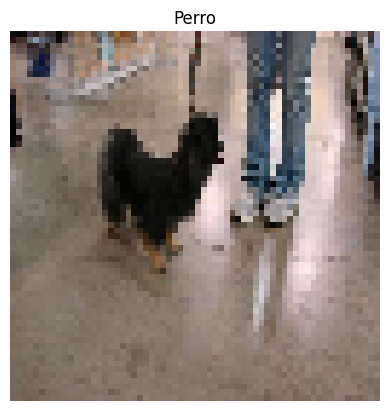

In [75]:
from keras.preprocessing import image
import numpy as np # Ensure numpy is imported
import matplotlib.pyplot as plt # Ensure matplotlib is imported

gato = image.load_img(test_gatos_dir + "/cat.1000.jpg",target_size=(64,64))
perro = image.load_img(test_perros_dir + "/dog.1000.jpg",target_size=(64,64))
imagen_prueba = perro # Changed to gato to test cat prediction

test_image = image.img_to_array(imagen_prueba)
test_image = np.expand_dims(test_image,axis=0)
# Important: Rescale the image to match the training data preprocessing
test_image = test_image / 255.0

# The following line is for reference and doesn't affect prediction
training_set.class_indices

result = modelo.predict(test_image)
print("predicción : ",result)
prediction = result[0][0]

if prediction >= 0.5:
  print("Es un Perro")
  plt.imshow(imagen_prueba)
  plt.title('Perro')
  plt.axis('off')
  plt.show()
else:
  print("Es un gato")
  plt.imshow(imagen_prueba)
  plt.title('Gato')
  plt.axis('off')
  plt.show()

# GRAFICAMOS ACCURACY Y LOSS

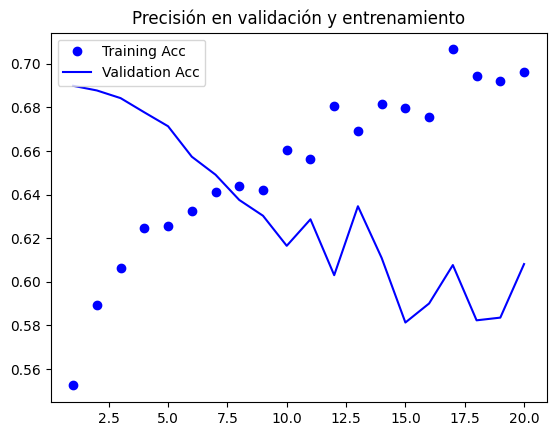

In [76]:
acc = history.history['accuracy']
val_acc = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs,acc,'bo',label='Training Acc')
plt.plot(epochs,val_acc,'b',label='Validation Acc')
plt.title('Precisión en validación y entrenamiento')
plt.legend()
plt.show()

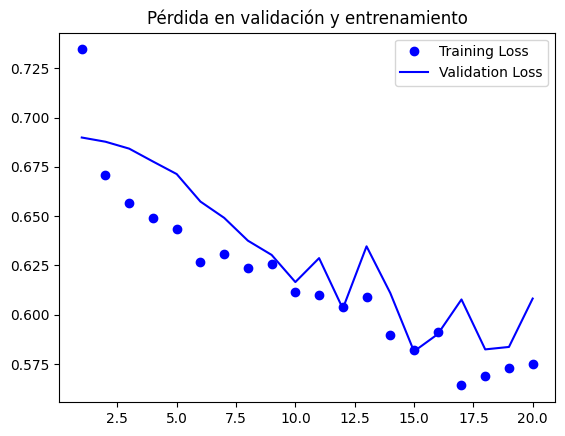

In [77]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs,loss,'bo',label='Training Loss')
plt.plot(epochs,val_loss,'b',label='Validation Loss')
plt.title('Pérdida en validación y entrenamiento')
plt.legend()
plt.show()

# GUARDAMOS EL MODELO ENTRENADO

In [78]:
modelo.save("modelo_perrosygatos.keras")

In [ ]:
import keras
red = keras.models.load_model('/content/modelo_perrosygatos.keras')
red